In [1]:
import pandas as pd

In [2]:
df_annotate = pd.read_csv("preprocessed_data_s2.csv")
df_annotate

,Unnamed: 0,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,...,agreement_is_noise_or_spam_text,agreement_related_to_election_2024,agreement_toxicity,agreement_polarized,agreement_profanity_obscenity,agreement_threat_incitement_to_violence,agreement_insults,agreement_identity_attack,agreement_sexually_explicit,cleaned_text
0,2,1-100,"['7', '15', '32']",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,...,True,False,False,True,True,True,False,True,True,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
1,19,1-1015,"['10', '18', '32']",Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,...,True,False,True,True,True,True,False,False,True,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...
2,20,1-1016,"['10', '18']",Video “Tentara Cina Komunis Tiongkok Masuk Ind...,Akun Facebook Imho Walleye (fb.com/10001818281...,Tionghoa,0,0,1,1,...,True,True,True,True,True,True,False,False,True,Video “Tentara Cina Komunis Tiongkok Masuk Ind...
3,25,1-1020,"['10', '18', '32']",Jokowi Bebaskan Pajak Selama 120 Tahun untuk W...,” Rezim Jokowi Menganggap Mereka seperti Teror...,UNKNOWN,0,0,1,1,...,True,True,True,True,True,True,False,True,True,Jokowi Bebaskan Pajak Selama 120 Tahun untuk W...
4,26,1-1021,"['10', '18']",GAMBAR GANJAR PRANOWO BERSALAMAN DENGAN PRESID...,“BERSIAPLAH INDONESIA AKAN DI MISKINKAN TERNYA...,UNKNOWN,0,1,1,1,...,True,True,True,True,False,True,False,True,True,GAMBAR GANJAR PRANOWO BERSALAMAN DENGAN PRESID...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,28369,4-928,"['19', '18']",@tanyakanrl Salah satu kejahatan dari houthi s...,NaN,Syiah,0,0,1,1,...,True,True,True,True,True,True,True,True,True,@tanyakanrl Salah satu kejahatan dari houthi s...
1964,28385,4-942,['19'],@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,...,True,True,True,True,True,True,True,True,True,@Heraloebss Usir Rohingya dari Aceh dan seluru...
1965,28390,4-947,['19'],Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,...,True,True,True,True,True,True,True,True,True,Bismillah... Semoga orang yang mati‑mati membe...
1966,28406,4-961,"['19', '18']","Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,...,True,True,True,True,True,False,True,False,True,"Gila ya, kalau umat bersatu habis juga itu ger..."


In [3]:
df_annotate.drop(columns =['Unnamed: 0', 'agreement_is_noise_or_spam_text', 'agreement_related_to_election_2024',
        'agreement_toxicity','agreement_polarized', 'agreement_profanity_obscenity', 'agreement_threat_incitement_to_violence',
        'agreement_insults','agreement_identity_attack', 'agreement_sexually_explicit'], inplace = True)

In [4]:
df_annotate.columns.to_list()

['text_id',
 'annotators_id',
 'text',
 'initial_paragraph',
 'topic',
 'is_noise_or_spam_text',
 'related_to_election_2024',
 'toxicity',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit',
 'cleaned_text']

In [5]:
df_annotator = pd.read_csv("annotator_demographic.csv")
df_annotator

,annotator_id,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,1,Tionghoa,Kristen,no,no,F,50,Jakarta,Diploma,Bekerja,2
1,2,Madura,Islam,no,no,F,22,Madura,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,3,Batak,Kepercayaan Lokal,no,no,F,29,Medan,Sarjana (S1),Bekerja,3
3,4,Bali,Hindu,no,no,M,23,Bandung,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,-
4,5,Jawa,Syiah,no,no,M,46,Bandung,Diploma,Bekerja,Golput
5,6,Minang,Ahmadiyah,no,no,F,22,Jakarta,Sarjana (S1),Bekerja,3
6,7,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
7,8,Arab,Islam,no,no,M,23,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,1
8,9,Jawa,Islam,no,no,F,21,Magelang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,2
9,10,Tionghoa,Buddha,no,no,F,20,Tangerang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3


In [6]:
annotate_columns = df_annotate.drop(['annotators_id', 'text_id'], axis=1).columns.to_list()
annotator_columns = df_annotator.drop(['annotator_id'], axis=1).columns.to_list()

print(annotate_columns)
print(annotator_columns)

['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text']
['ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning']


In [7]:
import ast

df_annotate["annotators_id"] = df_annotate["annotators_id"].apply(
    ast.literal_eval
)

df_annotate

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text
0,1-100,"[7, 15, 32]",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,0,0,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
1,1-1015,"[10, 18, 32]",Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,0,0,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...
2,1-1016,"[10, 18]",Video “Tentara Cina Komunis Tiongkok Masuk Ind...,Akun Facebook Imho Walleye (fb.com/10001818281...,Tionghoa,0,0,1,1,0,0,0,0,0,Video “Tentara Cina Komunis Tiongkok Masuk Ind...
3,1-1020,"[10, 18, 32]",Jokowi Bebaskan Pajak Selama 120 Tahun untuk W...,” Rezim Jokowi Menganggap Mereka seperti Teror...,UNKNOWN,0,0,1,1,0,0,0,1,0,Jokowi Bebaskan Pajak Selama 120 Tahun untuk W...
4,1-1021,"[10, 18]",GAMBAR GANJAR PRANOWO BERSALAMAN DENGAN PRESID...,“BERSIAPLAH INDONESIA AKAN DI MISKINKAN TERNYA...,UNKNOWN,0,1,1,1,0,0,0,0,0,GAMBAR GANJAR PRANOWO BERSALAMAN DENGAN PRESID...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,4-928,"[19, 18]",@tanyakanrl Salah satu kejahatan dari houthi s...,NaN,Syiah,0,0,1,1,0,0,0,1,0,@tanyakanrl Salah satu kejahatan dari houthi s...
1964,4-942,[19],@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,0,1,0,1,0,@Heraloebss Usir Rohingya dari Aceh dan seluru...
1965,4-947,[19],Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,0,0,0,1,0,Bismillah... Semoga orang yang mati‑mati membe...
1966,4-961,"[19, 18]","Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,0,0,"Gila ya, kalau umat bersatu habis juga itu ger..."


In [8]:
df_annotate_exp = df_annotate.explode("annotators_id")
df_annotate_exp = df_annotate_exp.rename(
    columns={"annotators_id": "annotator_id"}
)
df_annotate_exp

,text_id,annotator_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text
0,1-100,7,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,0,0,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
0,1-100,15,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,0,0,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
0,1-100,32,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,0,0,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
1,1-1015,10,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,0,0,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...
1,1-1015,18,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,0,0,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,4-942,19,@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,0,1,0,1,0,@Heraloebss Usir Rohingya dari Aceh dan seluru...
1965,4-947,19,Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,0,0,0,1,0,Bismillah... Semoga orang yang mati‑mati membe...
1966,4-961,19,"Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,0,0,"Gila ya, kalau umat bersatu habis juga itu ger..."
1966,4-961,18,"Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,0,0,"Gila ya, kalau umat bersatu habis juga itu ger..."


In [9]:
df_annotate_exp["annotator_id"] = df_annotate_exp["annotator_id"].astype(str)
df_annotator["annotator_id"] = df_annotator["annotator_id"].astype(str)

In [10]:
df = df_annotate_exp.merge(
    df_annotator,
    on="annotator_id",
    how="left"
)
df = df.drop(['text_id', 'annotator_id'], axis=1)
df

,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,...,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,...,Minang,Islam,yes,no,F,27.0,Padang,Sarjana (S1),Bekerja,1
1,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,...,Tionghoa,Katolik,yes,no,F,21.0,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,...,Tionghoa,Buddha,no,no,F,20.0,Tangerang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
4,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,...,Bali,Hindu,yes,no,M,34.0,Jakarta,Magister (S2),Tidak Bekerja,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5712,@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,0,1,0,...,Batak,Kristen,no,no,F,39.0,Depok,Magister (S2),Bekerja,2
5713,Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,0,0,0,...,Batak,Kristen,no,no,F,39.0,Depok,Magister (S2),Bekerja,2
5714,"Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,...,Batak,Kristen,no,no,F,39.0,Depok,Magister (S2),Bekerja,2
5715,"Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,...,Bali,Hindu,yes,no,M,34.0,Jakarta,Magister (S2),Tidak Bekerja,2


#Preprocessing

In [11]:
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "yg": "yang",
    "lu": "kamu",
    "loe": "kamu",
    "gw": "saya",
    "gue": "saya",
    "bgt": "banget",
    "dgn": "dengan",
    "krn": "karena",
    "aja": "saja",
    "trs": "terus"
}

In [12]:
import re

def normalize_slang(text, slang_dict):
    words = text.split()
    return " ".join([slang_dict.get(w.lower(), w) for w in words])

def preprocess_text(text, slang_dict, lowercase=True):
    if not isinstance(text, str):
        return ""

    # 1. remove username (@user)
    text = re.sub(r'@\w+', '', text)

    # 2. remove URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. remove unwanted symbols (keep .,!?)
    text = re.sub(r'[^\w\s.,!?]', '', text)

    # 5. normalize slang
    text = normalize_slang(text, slang_dict)

    # 6. normalize repeated chars (contoh: anjiiing → anjiing)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. lowercase (optional)
    if lowercase:
        text = text.lower()

    # 8. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [13]:
from tqdm import tqdm
tqdm.pandas()

df["processed_text"] = (
    df["cleaned_text"]
    .fillna("")
    .astype(str)
    .progress_apply(
        lambda x: preprocess_text(x, slang_dict)
    )
)

100%|██████████| 5717/5717 [00:00<00:00, 18087.50it/s]


#Stage 1

In [14]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

In [15]:
x = df.drop(columns=['toxicity'])
y = df['toxicity']

In [16]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})

In [18]:
print(dataset["train"].column_names)

['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'processed_text', '__index_level_0__']


In [19]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in annotator_columns:

    le = LabelEncoder()

    df[col] = df[col].astype(str)

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

In [20]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

def tokenize(batch):

    combined_texts = []

    for i in range(len(batch["processed_text"])):

        metadata_text = (
            f"Annotator memiliki etnis {batch['ethnicity'][i]}, "
            f"agama {batch['religion'][i]}, "
            f"status disabilitas {batch['disability'][i]}, "
            f"status LGBT {batch['lgbt'][i]}, "
            f"gender {batch['gender'][i]}, "
            f"usia {batch['age'][i]}, "
            f"berdomisili di {batch['domisili'][i]}, "
            f"pendidikan terakhir {batch['pendidikan terakhir'][i]}, "
            f"status pekerjaan {batch['status pekerjaan'][i]}, "
            f"dan kecenderungan pilihan presiden {batch['president vote leaning'][i]}."
        )

        combined_text = (
            f"{metadata_text} "
            f"Komentar yang dianotasi: {batch['processed_text'][i]}"
        )

        combined_texts.append(combined_text)
    print(combined_texts[0])

    tokenized = tokenizer(
        combined_texts,
        padding="max_length",
        truncation=True,
        max_length=128
    )

    tokenized["combined_text"] = combined_texts
    tokenized["labels"] = batch["toxicity"]

    return tokenized

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [21]:
tokenized_datasets_1 = dataset.map(
    tokenize,
    batched=True
)
print(tokenized_datasets_1)

Map:   0%|          | 0/4573 [00:00<?, ? examples/s]

Annotator memiliki etnis Aceh, agama Islam, status disabilitas no, status LGBT no, gender F, usia 39.0, berdomisili di Banda Aceh, pendidikan terakhir Doktor (S3), status pekerjaan Bekerja, dan kecenderungan pilihan presiden 3. Komentar yang dianotasi: penyebaran nyamuk wolbachia adalah misi bill gates, menyebabkan kerusakan genetik
Annotator memiliki etnis Tobelo, agama Islam, status disabilitas no, status LGBT no, gender M, usia 36.0, berdomisili di Ternate, pendidikan terakhir Sarjana (S1), status pekerjaan Bekerja, dan kecenderungan pilihan presiden 1. Komentar yang dianotasi: capek banget punya adek sepupu yang mengajak nikah terus. orang
Annotator memiliki etnis Sunda, agama Islam, status disabilitas no, status LGBT no, gender M, usia 43.0, berdomisili di Jakarta, pendidikan terakhir Magister (S2), status pekerjaan Bekerja, dan kecenderungan pilihan presiden 2. Komentar yang dianotasi: b assalamualaikum warahmatullahi jika ada yang bisa menemukan satu saja riwayat shahih salah sa

Map:   0%|          | 0/1144 [00:00<?, ? examples/s]

Annotator memiliki etnis Batak, agama Kepercayaan Lokal, status disabilitas no, status LGBT no, gender F, usia 29.0, berdomisili di Medan, pendidikan terakhir Sarjana (S1), status pekerjaan Bekerja, dan kecenderungan pilihan presiden 3. Komentar yang dianotasi: tnpa bermaksud menggurui pilih la pemimpin yang telah berpengalaman , pya rekam jejak yang jelas, elektabilitas dan kredibilitas nya mumpuni . di gembleng dr bawah dan ta pernah cacat hukum bkn yang instan sprti indomie
Annotator memiliki etnis Bali, agama Hindu, status disabilitas no, status LGBT no, gender M, usia 23.0, berdomisili di Bandung, pendidikan terakhir Sekolah Menengah Atas (SMA), status pekerjaan Pelajar/Mahasiswa, dan kecenderungan pilihan presiden -. Komentar yang dianotasi: hanya orang bodoh dan tolol yang benci sama anis ..
DatasetDict({
    train: Dataset({
        features: ['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity

In [22]:
tokenized_datasets_1 = tokenized_datasets_1.remove_columns([
    "processed_text",
    "cleaned_text",
    "toxicity",
    "text",
    "__index_level_0__"
] + annotator_columns)

print(tokenized_datasets_1["train"].column_names)

tokenized_datasets_1.set_format("torch")

['initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'input_ids', 'token_type_ids', 'attention_mask', 'combined_text', 'labels']


In [23]:
from transformers import AutoModelForSequenceClassification

model_s1 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
def compute_metrics_s1(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [25]:
from transformers import TrainingArguments, Trainer

args_s1 = TrainingArguments(
    output_dir="./model_toxicity",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_s1 = Trainer(
    model=model_s1,
    args=args_s1,
    train_dataset=tokenized_datasets_1['train'],
    eval_dataset=tokenized_datasets_1['test'],
    compute_metrics=compute_metrics_s1
)


In [26]:
trainer_s1.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.002801,0.051242,0.991259,0.995610
2,0.000403,0.037901,0.993007,0.996485
3,0.000233,0.031007,0.995629,0.997798
4,0.001941,0.029291,0.994755,0.997357
5,0.000123,0.030795,0.994755,0.997359


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2860, training_loss=0.029979697728509832, metrics={'train_runtime': 758.5936, 'train_samples_per_second': 30.141, 'train_steps_per_second': 3.77, 'total_flos': 1504008570201600.0, 'train_loss': 0.029979697728509832, 'epoch': 5.0})

In [27]:
history = trainer_s1.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs = [x['epoch'] for x in history if 'eval_loss' in x]

In [28]:
from matplotlib import pyplot as plt

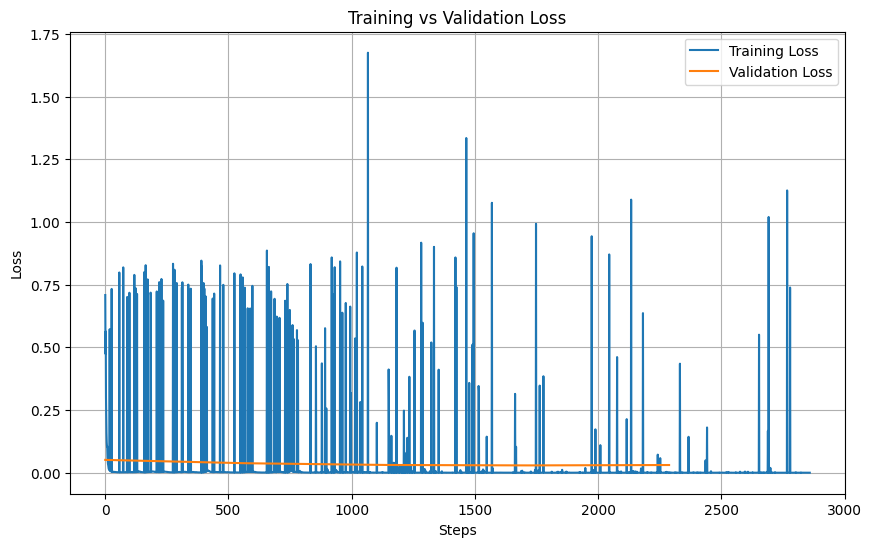

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(range(0, len(train_loss), len(train_loss)//len(val_loss)), val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

#Stage 2

In [30]:
LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

In [31]:
df_2 = df[df['toxicity'] == 1]
y = df_2[LABEL_COLS]

In [32]:
from sklearn.model_selection import train_test_split

train_df_s2, test_df_s2 = train_test_split(
    df_2,
    test_size=0.2,
    random_state=42
)

In [33]:
from datasets import Dataset, DatasetDict

dataset_s2 = DatasetDict({

    "train": Dataset.from_pandas(
        train_df_s2.reset_index(drop=True)
    ),

    "test": Dataset.from_pandas(
        test_df_s2.reset_index(drop=True)
    )
})

In [34]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

def tokenize_multilabel(batch):

    combined_texts = []

    for i in range(len(batch["processed_text"])):

        metadata_text = (
            f"Annotator memiliki etnis {batch['ethnicity'][i]}, "
            f"agama {batch['religion'][i]}, "
            f"status disabilitas {batch['disability'][i]}, "
            f"status LGBT {batch['lgbt'][i]}, "
            f"gender {batch['gender'][i]}, "
            f"usia {batch['age'][i]}, "
            f"berdomisili di {batch['domisili'][i]}, "
            f"pendidikan terakhir {batch['pendidikan terakhir'][i]}, "
            f"status pekerjaan {batch['status pekerjaan'][i]}, "
            f"dan kecenderungan pilihan presiden {batch['president vote leaning'][i]}."
        )

        combined_text = (
            f"{metadata_text} "
            f"Komentar yang dianotasi: {batch['processed_text'][i]}"
        )

        combined_texts.append(combined_text)

    tokenized = tokenizer(
        combined_texts,
        padding="max_length",
        truncation=True,
        max_length=128
    )

    # multilabel targets
    tokenized["labels"] = [
        [float(batch[col][i]) for col in LABEL_COLS]
        for i in range(len(batch["processed_text"]))
    ]

    tokenized["combined_text"] = combined_texts

    return tokenized

In [35]:
tokenized_datasets_2 = dataset_s2.map(
    tokenize_multilabel,
    batched=True
)

Map:   0%|          | 0/4532 [00:00<?, ? examples/s]

Map:   0%|          | 0/1134 [00:00<?, ? examples/s]

In [36]:
tokenized_datasets_2 = tokenized_datasets_2.remove_columns([
    "text",
    "initial_paragraph",
    "topic",
    "is_noise_or_spam_text",
    "related_to_election_2024",
    "toxicity",
    "polarized",
    "cleaned_text",
    "processed_text"
] + annotator_columns + LABEL_COLS)

In [37]:
from transformers import AutoModelForSequenceClassification

model_2 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
import numpy as np
from sklearn.metrics import (
    f1_score,
    accuracy_score
)

def compute_metrics_multilabel(eval_pred):

    logits, labels = eval_pred

    predictions = (logits > 0).astype(int)

    f1_micro = f1_score(
        labels,
        predictions,
        average="micro"
    )

    f1_macro = f1_score(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "f1_micro": f1_micro,
        "f1_macro": f1_macro
    }

In [39]:
from transformers import TrainingArguments, Trainer

args_s2 = TrainingArguments(
    output_dir="./model_toxicity",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_s2 = Trainer(
    model=model_2,
    args=args_s2,
    train_dataset=tokenized_datasets_2['train'],
    eval_dataset=tokenized_datasets_2['test'],
    compute_metrics=compute_metrics_multilabel
)


In [40]:
batch = tokenized_datasets_2["train"][:2]

print(batch["labels"])

[[0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0, 0.0]]


In [41]:
trainer_s2.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro
1,0.265163,0.247712,0.581129,0.585400,0.430411
2,0.092142,0.195785,0.708995,0.746634,0.616500
3,0.093956,0.173087,0.749559,0.783816,0.650216
4,0.054426,0.162346,0.779541,0.819429,0.738568
5,0.072013,0.151264,0.805115,0.829356,0.748910


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2835, training_loss=0.19013622537570657, metrics={'train_runtime': 689.1884, 'train_samples_per_second': 32.879, 'train_steps_per_second': 4.114, 'total_flos': 1490564277058560.0, 'train_loss': 0.19013622537570657, 'epoch': 5.0})

In [42]:
import numpy as np

predictions = trainer_s2.predict(
    tokenized_datasets_2["test"]
)

logits = predictions.predictions
labels = predictions.label_ids

probs = 1 / (1 + np.exp(-logits))

preds = (probs >= 0.5).astype(int)

In [43]:
from sklearn.metrics import classification_report

for i, label_name in enumerate(LABEL_COLS):

    print(f"\n===== {label_name} =====")

    print(
        classification_report(
            labels[:, i],
            preds[:, i]
        )
    )


===== insults =====
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       796
         1.0       0.84      0.84      0.84       338

    accuracy                           0.90      1134
   macro avg       0.88      0.89      0.89      1134
weighted avg       0.90      0.90      0.90      1134


===== identity_attack =====
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       794
         1.0       0.84      0.84      0.84       340

    accuracy                           0.91      1134
   macro avg       0.89      0.89      0.89      1134
weighted avg       0.91      0.91      0.91      1134


===== threat_incitement_to_violence =====
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      1103
         1.0       1.00      0.19      0.32        31

    accuracy                           0.98      1134
   macro avg       0.99      0.60  

In [44]:
import numpy as np
import torch

LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

def predict_multilabel(
    text,
    ethnicity,
    religion,
    disability,
    lgbt,
    gender,
    age,
    domisili,
    pendidikan,
    pekerjaan,
    president_vote
):

    metadata_text = (
        f"Annotator memiliki etnis {ethnicity}, "
        f"agama {religion}, "
        f"status disabilitas {disability}, "
        f"status LGBT {lgbt}, "
        f"gender {gender}, "
        f"usia {age}, "
        f"berdomisili di {domisili}, "
        f"pendidikan terakhir {pendidikan}, "
        f"status pekerjaan {pekerjaan}, "
        f"dan kecenderungan pilihan presiden {president_vote}."
    )

    combined_text = (
        f"{metadata_text} "
        f"Komentar yang dianotasi: {text}"
    )

    inputs = tokenizer(
        combined_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():

        outputs = model_2(**inputs)

        probs = torch.sigmoid(
            outputs.logits
        ).cpu().numpy()[0]

    predictions = (probs >= 0.5).astype(int)

    result = {}

    for label, pred, prob in zip(
        LABEL_COLS,
        predictions,
        probs
    ):
        result[label] = {
            "prediction": int(pred),
            "probability": float(prob)
        }

    return {
        "combined_text": combined_text,
        "results": result
    }

In [45]:
predict_multilabel(
    text="dasar goblok banget lu",
    ethnicity="jawa",
    religion="islam",
    disability="tidak",
    lgbt="tidak",
    gender="perempuan",
    age="24",
    domisili="bandung",
    pendidikan="S1",
    pekerjaan="mahasiswa",
    president_vote="kandidat A"
)

RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)